<h1><center>Laboratorio 10: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>

### **Cuerpo Docente:**

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Renato Pino
- Nombre de alumno 2: Valentina Abello



### **Link de repositorio de GitHub:** [Repositorio](https://github.com/Renato-98/MDS7202-1)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = '/content/drive/MyDrive/Lab_progra_DS/Lab_10/' # Ajustar al path propio
except:
    print('Ignorando conexión drive-colab')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv(path + 'diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [ ]:
!pip install xgboost

In [ ]:
# Inserte su código aquí
#1.
# Realice una breve exploración de los datos y determine si aplicará transformaciones
import pandas as pd
import numpy as np

display(df.info())  # Tipos de datos, valores nulo
display(df.describe())  # Estadísticas para variables numéricas

# Observa las primeras filas
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke             

None

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


Aunque todos los datos son floats, al ver las primeras 5 filas del dataset parece que varios datos son del binarios (1 o 0) como el mismo Diabetes que imagino es {Tener diabetes: 1, No tener diabetes: 0}

Veamoslo:

In [ ]:
# Printeamos los dtos unicos para cada columna
for col in df.columns:
    print(f"{col}:")
    print(df[col].unique())
    print("\n")

Age:
[ 4. 12. 13. 11.  8.  1.  6.  3.  7. 10.  9.  5.  2.]


Sex:
[1. 0.]


HighChol:
[0. 1.]


CholCheck:
[1. 0.]


BMI:
[26. 28. 29. 18. 31. 32. 27. 24. 21. 58. 30. 20. 22. 38. 40. 25. 36. 47.
 19. 37. 41. 23. 34. 35. 42. 17. 33. 44. 15. 52. 69. 56. 45. 39. 92. 53.
 98. 50. 46. 79. 48. 16. 63. 72. 54. 49. 68. 43. 84. 73. 76. 55. 51. 75.
 57. 60. 12. 77. 82. 67. 71. 61. 14. 81. 59. 86. 13. 87. 65. 95. 89. 62.
 64. 66. 85. 70. 83. 80. 78. 74.]


Smoker:
[0. 1.]


HeartDiseaseorAttack:
[0. 1.]


PhysActivity:
[1. 0.]


Fruits:
[0. 1.]


Veggies:
[1. 0.]


HvyAlcoholConsump:
[0. 1.]


GenHlth:
[3. 1. 2. 4. 5.]


MentHlth:
[ 5.  0.  7.  3.  4.  2. 30. 20.  1. 15. 10. 25. 14. 28.  6. 29. 26. 12.
 16. 22. 13.  8.  9. 21. 18. 17. 27. 24. 23. 11. 19.]


PhysHlth:
[30.  0. 10.  3.  6.  4. 15.  1.  2. 14.  7. 25. 21. 20.  5.  8. 22. 23.
 29. 12. 18. 28. 26. 24. 27. 11. 13. 16. 17.  9. 19.]


DiffWalk:
[0. 1.]


Stroke:
[0. 1.]


HighBP:
[1. 0.]


Diabetes:
[0. 1.]




Curioso que los valores de edad solo vayan desde 1 a 13, imaginamos que ya estaría estandarizado.

Veamos la correlacion que hay entre las variables del dataset.

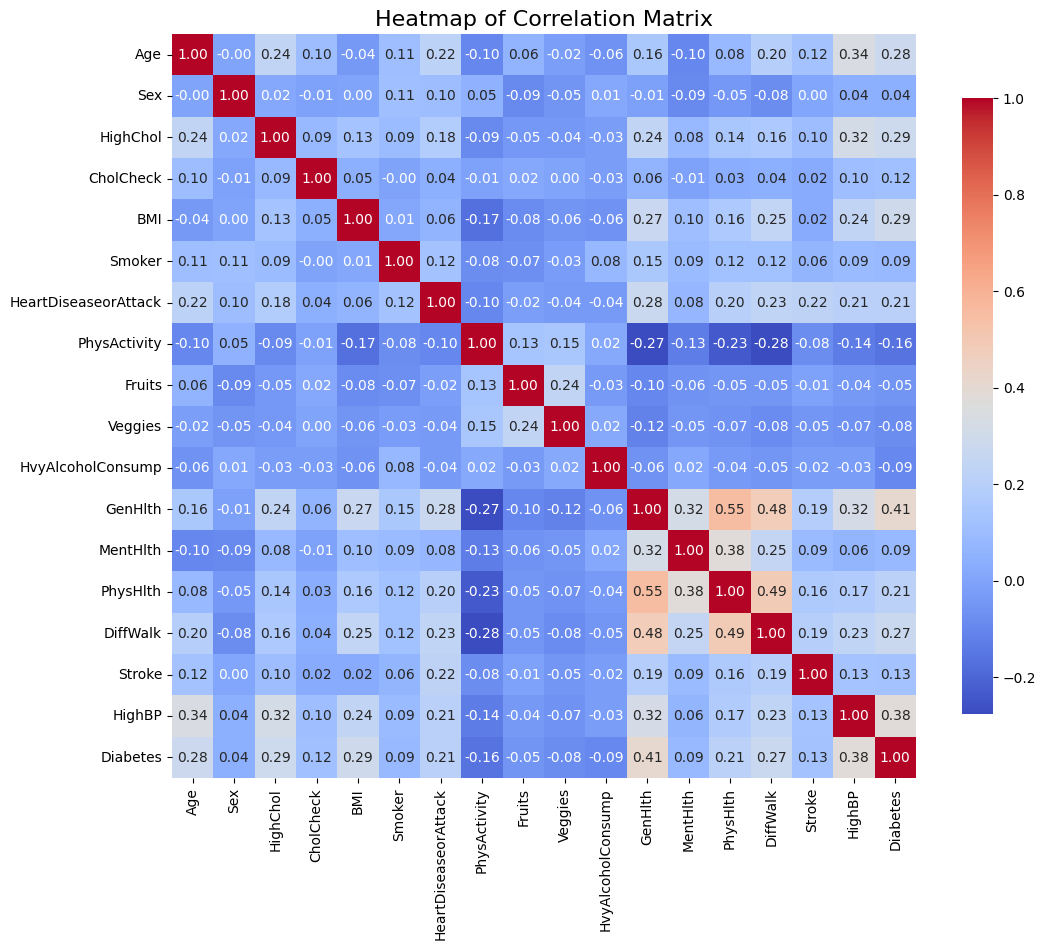

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

# Define figura más grande
plt.figure(figsize=(12, 10))  # Ancho de 12 y alto de 10
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Heatmap of Correlation Matrix', fontsize=16)
plt.show()

Tomando en cuenta los niveles de correlacion son moderadamente bajos (a excepcion de unas pocas variablkes de percepcion propia, como las termidandas en 'Hlth' ) usaremos todas las variables para entrenar e interpretar el modelo.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# # Definimos las columnas numericas que vamos a escalar
# numeric_features = ["Age", "BMI", "GenHlth", "MentHlth", "PhysHlth"]

# # Definimos el ColumnTransformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_features)
#     ],
#     remainder='passthrough',  # Mantenemos las variables binarias sin transformar
#     verbose_feature_names_out=False  # Mantenemos los nombres originales de las columnas
# )

# Creeamos el conjunto de entrenamiento y de prueba
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) # 0.33 de test porque piden 1/3 de test jeje
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((47363, 17), (23329, 17), (47363,), (23329,))

Originalmente decidimos realizar un standarscaler para todas las columnas numericas no binarias pero finalemnte decisimos que o es necesario hacer ningun escalamiento ni transformacion porque:

* Xgboost es invariante a scaling
* Ya que nuestro objetivo es la interpretabilidad ajustar las escalas podria darnos resultados diferentes en los calculos de feature importance (cosa que nos paso).Asi que consideramos que, sin escalado, la interpretación de la importancia de las caracteristicas es mas directa y alineada con el contexto original de los datos.
* Las metricas obtenidas por el modelo con y sin escalado son las mismas.
* Al obtener explicaciones con AnchorTabular obteniamos warnings del estilo : 'For feature x, no training data record had discretized values in bins{2}'. Pero este problema no esta presente con los datos originales.

Por tanto, **determinamos que no haremos ninguna transformacion con los datos**.

In [ ]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report

# Definimos el pipeline
pipeline = Pipeline(steps=[
    # ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42))
])

# Entrenamiento del modelo
pipeline.fit(X_train, y_train)

# Prediccion y evaluacion
y_pred = pipeline.predict(X_test)

# Calculo de metricas
mae = mean_absolute_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Imprimir resultados
print(f'MAE: {mae}\n')
print(f'Accuracy: {accuracy}\n')
print('Classification Report:')
print(classification_rep)

MAE: 0.253761412833812

Accuracy: 0.746238587166188

Classification Report:
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74     11651
         1.0       0.73      0.79      0.76     11678

    accuracy                           0.75     23329
   macro avg       0.75      0.75      0.75     23329
weighted avg       0.75      0.75      0.75     23329



1. ***¿Es acaso un buen predictor de diabetes?***

Basandonos en el classification report, el modelo tiene una exactitud del 75% y un F1-score de 0.74 y 0.76  en las clases 0.0 y 1.0 respectivamente. Esto indica que el modelo tiene un rendimiento uniforme en la clasificación de casos positivos y negativos de diabetes. Aunque no es perfecto, muestra una capacidad aceptable para diferenciar entre pacientes con y sin diabetes. Sin embargo, el rendimiento podría ser mejorado con ajustes adicionales (como optimización de hiperparámetros o selección de características relevantes).

---

2. ***¿Qué buscan explicar las métricas utilizadas?***

Las métricas precisión, recall y F1-score buscan evaluar distintos aspectos del rendimiento del modelo:

* Precision: Indica la proporcion de predicciones positivas que fueron correctas. Una precisión alta es importante cuando los falsos positivos tienen un costo alto.
* Recall: Mide la proporcion de casos positivos correctamente identificados. En problemas medicos, como la detección de diabetes, un recall alto es critico para no dejar casos de diabetes sin detectar, por lo qjue considero que es la metrica mas importante para este problema.
* F1-score: Es la media armónica de precision y recall, proporcionando un equilibrio entre ambos. Es util cuando ambas metricas son relevantes y se busca un rendimiento equilibrado.

---

3. ***¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?***

No necesariamente. Las metricas de rendimiento reflejan que tan bien el modelo predice el resultado, pero no indican directamente si las features elegidas son las óptimas o si el modelo esta usando las caracteristicas correctas para hacer las predicciones.

Para asegurarse de que el modelo hace una buena eleccion de las features, es necesario realizar un analisis de importancia de caracteristicas o interpretabilidad, como con valores SHAP o importancia de features en XGBoost. Estas herramientas permitiran evaluar la influencia de cada variable en las predicciones, lo cual es clave para entender si el modelo se esta basando en patrones significativos

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

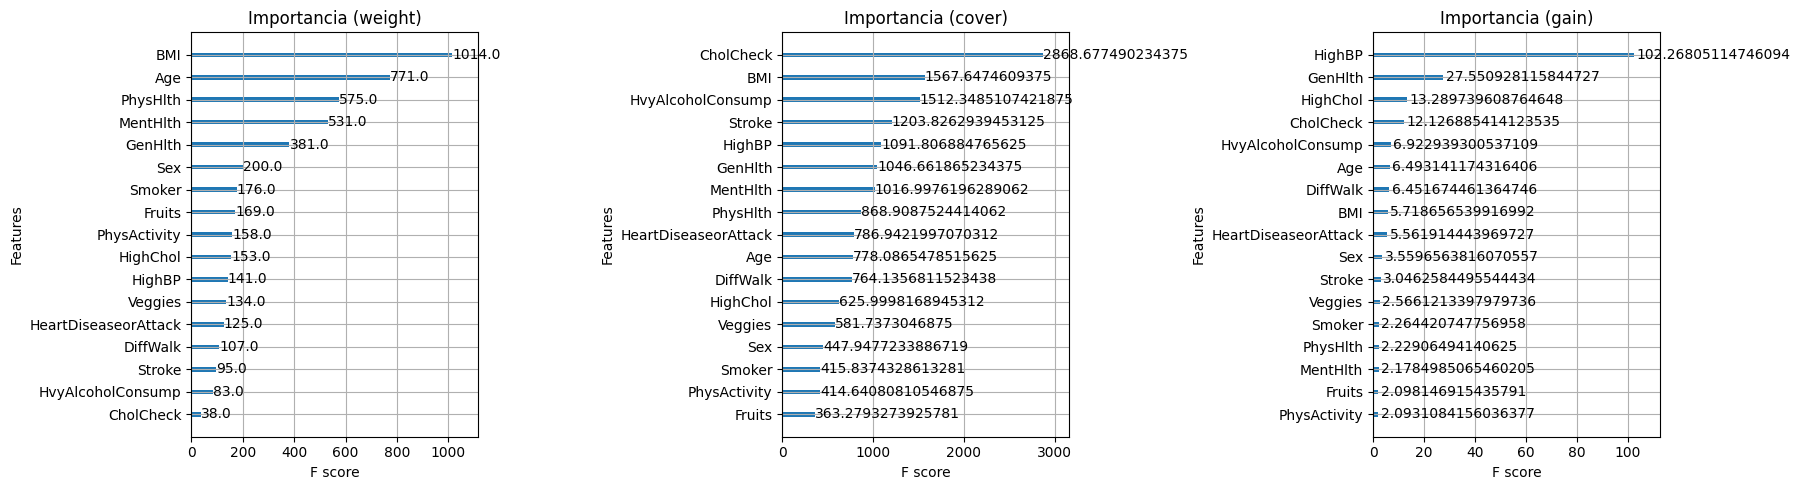

In [ ]:
# Inserte su código aquí
#1.
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Accedemos al modelo XGBoost desde el pipeline
xgb_model = pipeline.named_steps['classifier']

# Obtener los nombres de las features transformadas
#feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = X_train.columns.tolist()

# Parametros de la gráfica
importance_types = ['weight', 'cover', 'gain']
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Genera la importancia de las características para cada tipo
for i, imp_type in enumerate(importance_types):
    plot_importance(xgb_model, importance_type=imp_type, ax=axs[i], title=f'Importancia ({imp_type})')

    # Obtenemos la importancia de las caracteristicas y las ordenamos por el tipo de importancia actual
    feature_importances = xgb_model.get_booster().get_score(importance_type=imp_type)
#    sorted_idx = [int(k[1:]) for k in sorted(feature_importances, key=feature_importances.get, reverse=True)]

    # Sacamos los nombres correspondientes de las variables
#    imp_feature_names = [feature_names[idx] for idx in sorted_idx]

#    axs[i].set_yticklabels(imp_feature_names)

plt.tight_layout()
plt.show()

2. Podemos ver que los 3 metodos nos dan distintos ordenes de feature importance. Las diferencias pueden deberse a como cada metodo define “importancia”. Gain tiende a resaltar las features que contribuyen mas a la reducción de error, mientras que Cover y Weight destacan las caracteristicas frecuentemente utilizadas.

3. Las importancias de features en XGBoost ayudan a entender cuales variables influyen en el modelo. Sin embargo, no muestran como los valores especificos de las variables afectan las predicciones, por lo que no creo que este analisis de importancia sea suficiente para obtener la interpretabilidad a nivel de feature global. Aqui es donde tecnicas como SHAP son    utiles para obtener interpretaciones más detalladas y especificas de cada predicción. Una debilidad de este metodo es que a veces falla en reflejar la verdadera importancia de las variables debido a la correlación que puede existir entre ellas. Si las caracteristicas estan altamente correlacionadas, el metodo puede asignar la importancia a una de ellas mientras ignora la otra, lo que lleva a una interpretación engañosa sobre cual es realmente más influyente en el modelo

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [ ]:
# Inserte su código aquí

# 1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
from sklearn.inspection import permutation_importance

# Obtenemos los nombres de las features
feature_names = X_train.columns.tolist()

print(feature_names)

# 2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
results = permutation_importance(pipeline, X_test, y_test, n_repeats=30, random_state=42)

importances = results.importances_mean
stds = results.importances_std
indices = np.argsort(importances)[::-1]

for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.3f} +/- {stds[i]:.3f}")

['Age', 'Sex', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Stroke', 'HighBP']
GenHlth: 0.053 +/- 0.002
BMI: 0.030 +/- 0.002
Age: 0.026 +/- 0.002
HighBP: 0.017 +/- 0.001
HighChol: 0.011 +/- 0.001
HeartDiseaseorAttack: 0.004 +/- 0.001
CholCheck: 0.003 +/- 0.001
HvyAlcoholConsump: 0.003 +/- 0.000
DiffWalk: 0.002 +/- 0.001
Stroke: 0.002 +/- 0.000
MentHlth: 0.001 +/- 0.001
Sex: 0.001 +/- 0.001
PhysHlth: 0.001 +/- 0.001
PhysActivity: 0.000 +/- 0.001
Veggies: 0.000 +/- 0.000
Smoker: -0.000 +/- 0.001
Fruits: -0.000 +/- 0.001


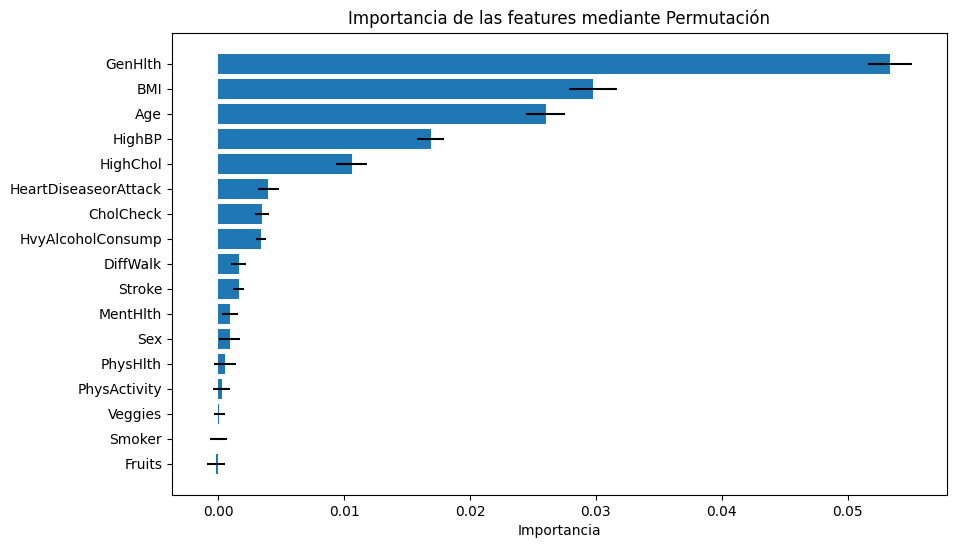

In [ ]:
# 3. Visualice los resultados de este método en un gráfico. (2 puntos)
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[indices], importances[indices], align='center', xerr=stds[indices])
plt.xlabel('Importancia')
plt.title('Importancia de las features mediante Permutación')
plt.gca().invert_yaxis()
plt.show()

4.
- **¿Cómo mide la importancia de las features su propuesta?**

Se mide evaluando en cómo cambia el rendimiento del modelo cuando se permutan aleatoriamente los valores de una feature a la vez, por ejemplo, si una feature disminuye significativamente el rendimiento de nuestro modelo, entonces ésta se considera importante, ya que, impacta negativamente a la capacidad predictiva del modelo.

- **¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido?**

  - `GenHlth`: Indica cómo la persona califica su estado de salud, que tiene sentido, dado que una menor calificación podría estar relacionado con poseer diabetes.
  - `BMI`: Indica el índice de masa corporal de la persona, el cual podría relacionarse que a un mayor BMI, que correspondería a una persona con sobrepeso, más propenso sería de tener diabetes.
  - `Age`: Indica la edad de la persona categorizada en 13 niveles. Donde se podría relacionar que a mayor nivel de edad, mayor riesgo o probabilidad de tener diabetes.
  - `HighBP`: Indica si la persona ha sido diagnosticada con presión arterial alta, la cual se relaciona bastante con la diabetes y podría ser un indicador clave.
  - `HighCol`: Indica si la persona ha sido diagnosticada con un alto colesterol en sangre, que también podría ser un indicador clave para la diabetes.

   - (Basándonos en: [link](https://github.com/Helmy2/Diabetes-Health-Indicators/blob/main/diabetes.ipynb))

- **¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior?**

En comparación con el punto anterior, Gain resalta las features que más contribuyen a la reducción de error del modelo, mientras que Cover y Weight destacan las que se usan más frequentemente en las divisiones. En comparación con el método de Permutación, este mide la importancia de las features observando cómo la alteración de los valores en una feature impacta en el rendimiento del modelo, logrando una visión más directa del efecto que tendría esta feature en el modelo de acuerdo a la pérdida de precisión.

El método de permutación además, logra analizar mejor la correlación entre las variables, viendo el impacto que tiene cada feature al mantener las demás constantes, sin embargo, si la correlación es muy alta no logra identificar de buena manera las features más importantes. Para esto, como se mencionó en el punto anterior, técnicas como SHAP puede complementar a este método para mejores resultados.

- **Nombre y explique 3 ventajas y 3 desventajas del método implementado.**

- **Ventajas**
  - **Fácil interpretación**: El método es intuitivo de entender, dado que se basa en el impacto directo de alterar una feature en el rendimiento del modelo.

  - **Comparable con diferentes modelos**: El método se puede aplicar para cualquier otro modelo predictivo y no solamente a árboles de decisión, facilitando la comparación para distintos algoritmos.

  - **No necesita re-entrenar el modelo**: Como el modelo se basa en permutar los datos de entrada, no necesita volver a entrenar el modelo, siendo computacionalmente más eficiente en comparación con otros métodos.

- **Desventajas**
  - **Enlazado al error del modelo**: La medida de importancia del método está directamente relacionada con el error del modelo, limitando su precisión en caso que el modelo no fuera lo suficientemente robusto.

  - **Se necesita acceso al gold label**: Para poder calcular el impacto en el modelo es necesario tener las gold label (etiquetas reales) para así comparar las predicciones.

  - **Si las features están correlacionadas puede generar sesgos por entradas poco realistas**: Esto puede generar sesgos debido a la generación de entradas 'poco realistas' al permutar solo una feature mientras las demás permancen constantes.


## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [ ]:
!pip install shap

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

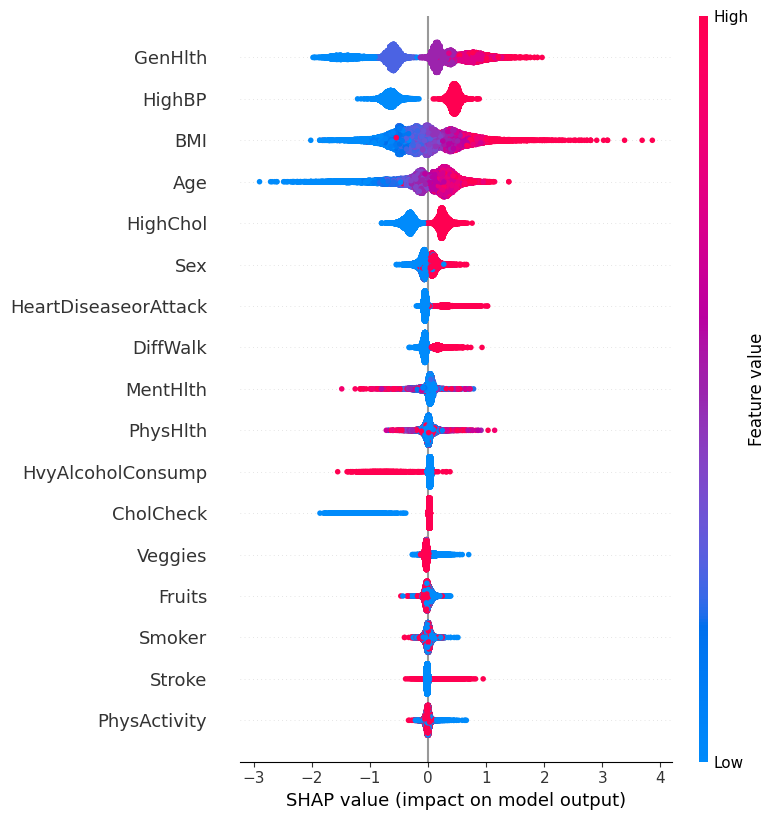

In [ ]:
# 1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista local). Para esto, el ilustre farmacéutico le pide calcular los shap values de su modelo. (2 puntos)
import shap

# Calculamos los shap values
explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dot")

In [ ]:
# Vemos el valor de la instancia x_1
shap_values[1]

.values =
array([ 0.6348514 , -0.12728687, -0.29119697,  0.01930101,  0.5168076 ,
        0.02817983, -0.07057241,  0.02806747, -0.00731437, -0.04295021,
        0.02025708,  0.23844229,  0.0418565 , -0.01089665,  0.11921006,
       -0.01595894, -0.61570835], dtype=float32)

.base_values =
-0.009056426

.data =
array([13.,  0.,  0.,  1., 33.,  1.,  0.,  0.,  1.,  1.,  0.,  3.,  0.,
        3.,  1.,  0.,  0.])

2. **¿Qué representa cada número en su resultado?**

Cada valor de `shap_values` indica la contribución de una variable específica en la predicción del modelo para un paciente en particular. Para los **valores positivos**, indica que esta variable **aumenta la probabilidad** de tener una predicción positiva, en nuestro caso que la persona tenga diabetes. Mientras que, los **valores negativos** disminuyen la probabilidad de que la persona tenga diabetes.

3. **¿Es posible atribuir un significado a la positividad/negatividad de cada valor?**

Sí, es posible atribuir un significado a la positividad/negatividad de cada valor dado lo que mencionó anteriormente.

  - **Valores positivos**: nos inidican que la variable contribuye a un aumento en la probabilidad de que la predicción sea positiva.
  - **Valores negativos**: nos inidican que la variable contribuye a una disminución en la probabilidad de que la predicción sea positiva.


### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

In [ ]:
# 1. Usando los shap values calculados, grafique el aporte local de las diferentes variables para las instancias 1, 9 y 150

instancias = [1, 9, 150]

for i in instancias:
    plot = shap.force_plot(
        shap_values.base_values[i],
        shap_values.values[i],
        X_test.iloc[i],
        link="logit"
    )
    # Guardamos el gráfico en un archivo HTML
    shap.save_html(f'shap_force_plot_instancia_{i}.html', plot)

from IPython.display import HTML

# Mostramos cada archivo
for i in instancias:
    print(f'Visualización para la instancia {i}')
    display(HTML(f'shap_force_plot_instancia_{i}.html'))

Visualización para la instancia 1


Visualización para la instancia 9


Visualización para la instancia 150


2.
  - **¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes?**

  De acuerdo a las instancias graficadas podemos concluir lo siguiente:

    - **Variables que afectan de manera positiva a la probabilidad de poseer diabetes**: (color rojo)
      - `Age = 13`: personas con mayor nivel de edad
      - `Sex = 1`: hombres
      - `BMI = 33`: índice de masa corporal igual a 33

    - **Variables que afectan de manera negativa a la probabilidad de poseer diabetes**: (color azul)
      - `HighBP = 0`: personas sin presión arterial alta
      - `GenHlth = 1`: personas que consideran que tienen un estado de salud 1 (asumiendo el más 'sano')
      - `BMI = 18`: personas con peso 'normal'

  - **¿Existe algún patrón común entre las instancias analizadas?**
  
  No realmente, si bien, se observa que algunas variables se repiten en las distintas instancias, algunas tienen distinto valor (como `GenHlth` que toma valor 1 en la instancia 9 y toma valor 2 en la instancia 150).

  - **¿Es posible generalizar estas conclusiones a todo el dataset?**

  No es posible generalizar estas conclusiones para todo el dataset, dado que se necesita un análisis global de todas las instancias y sus contribuciones promedio de cada una de las variables para poder ver obtener conclusiones generales.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

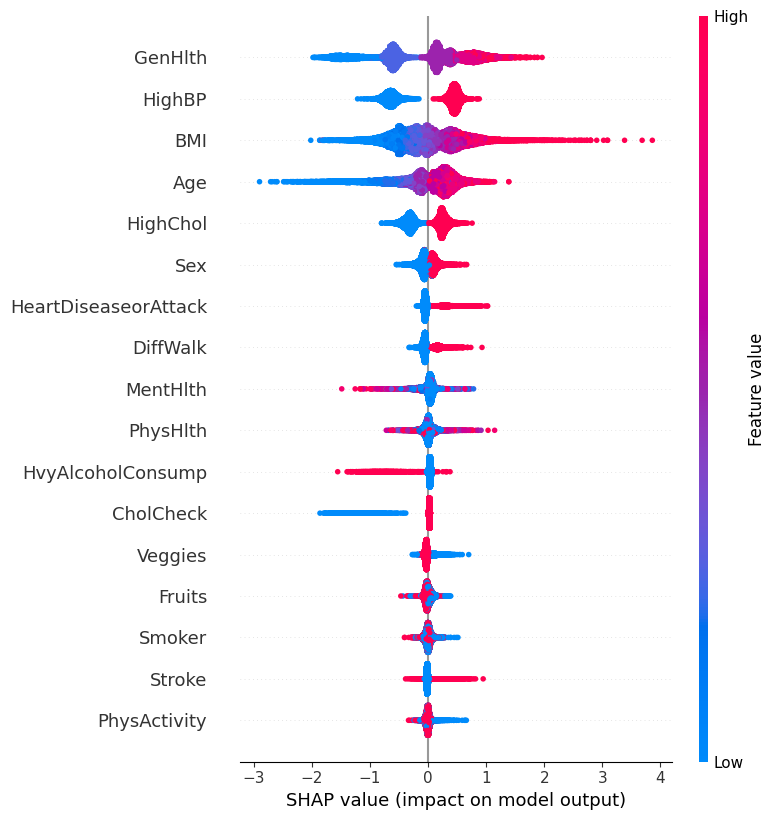

In [ ]:
# Inserte código para generar gráficos de aporte global aquí
# Genere ahora una visualización donde se grafique el aporte de cada feature a nivel global e interprete sus resultados.
shap.summary_plot(shap_values, X_test)

Del gráfico se puede concluir lo siguiente:

  - Para `GenHlth`, se observa que a medida que la calificación, en el estado de salud de las personas, aumenta, tienden a aumentar la probabilidad de que la persona tenga diabetes.
  - Para `HighBP` muestra que, para valores altos (rojos) donde `HighBP = 1`, su `shap value` es positivo, aumenta su probabilidad de diabetes. Mientras que, para personas con valors bajos (azules) donde `HighBP = 0`,  su `shap value` es negativo, disminuyendo su probabilidad de diabetes.
  - Para `BMI`, a un mayor índice de masa corporal este aumenta la probabilidad de poseer diabetes.

En cuanto a diferencias con las conclusiones obtenidas anteriormente por instacias, se puede decir que se le da más importancia a la variable `HighBP`, posicionándola en segunda lugar.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

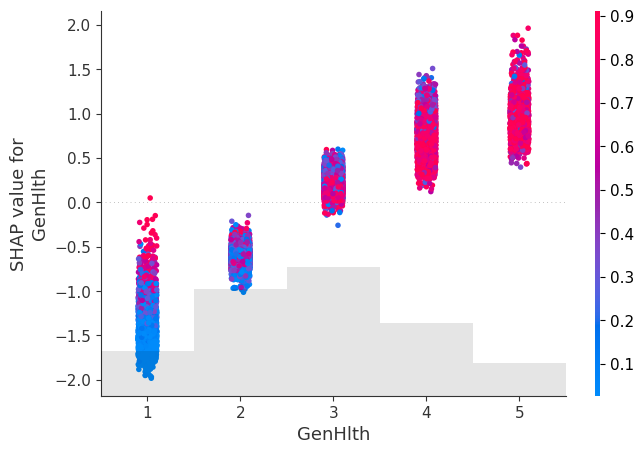

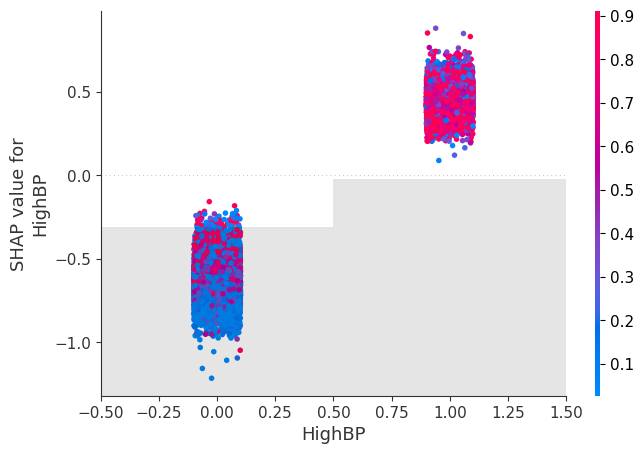

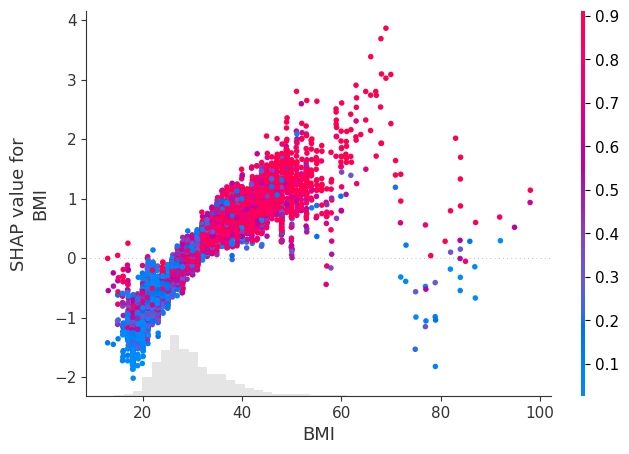

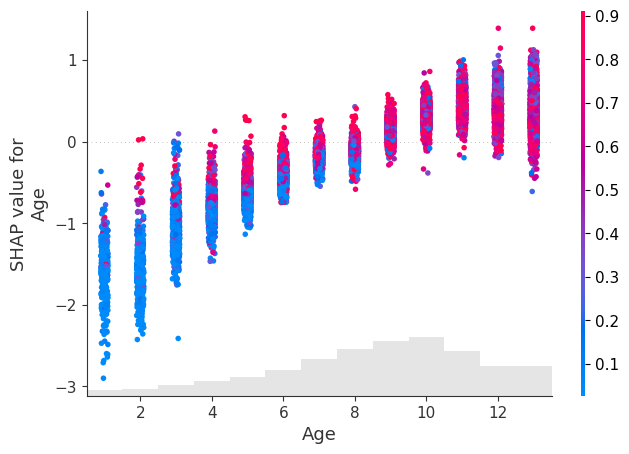

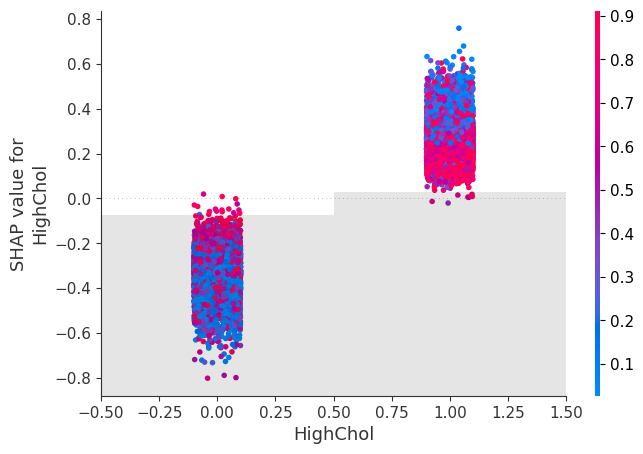

In [ ]:
# Inserte código para generar gráficos de feature vs shap value aquí
# Grafique ahora un scatterplot entre los shap values y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes.
import seaborn as sns

# Obtenemos las 5 primeras features con mayor impacto global
shap_values_abs = np.mean(np.abs(shap_values.values), axis=0)
top_features = X_test.columns[np.argsort(shap_values_abs)[-5:][::-1]]

# Generamos las probabilidades de tener diabetes
prob_diabetes = pipeline.predict_proba(X_test)[:, 1]

for name in top_features:
  shap.plots.scatter(shap_values[:, X_test.columns.get_loc(name)],color=prob_diabetes)


De los gráficos se puede concluir lo siguiente para las 5 features con mayor impacto global:

- `GenHlth`: al aumentar el nivel de salud de la persona, desde el nivel 3, se comienzan a observar un aumento en los puntos rojos, aumentando la probabildad de poseer diabetes, lo cual hace sentido con las conclusiones anteriores.

- `HighBP`: para personas sin presión arterial alta (`HighBP = 0`) se presenta mayormente puntos azules, que indican una menor probabilidad de presentar diabetes como se concluyó antes. Mientras que, para personas con presión arterial alta (`HighBP = 1`) se presenta en su mayoría puntos rojos, indicando diabetes.

- `BMI`: a medida que aumenta el índice de masa corporal, desde el 35 aproximadamente, se comienzan a observar una gran cantidad de puntos rojos en su mayoría, indicando diabebtes.

- `Age`: a medida que el nivel de rango de edad aumenta, también lo hace la probabilidad de poseer diabetes, sobre todo desde el nivel 9.

- `HighCol`: se puede observar que en las personas que han sigo diagnosticadas con colesterol alto (`HighCol = 1`), tienen una mayor probabilidad de presentar diabetes, del gráfico se ve que sería como aproximadamente el 50%.



### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

In [ ]:
df[df.BMI >= 75]['Diabetes'].value_counts()

,count
Diabetes,
1.0,60
0.0,58


In [ ]:
df[df.BMI >= 80]['Diabetes'].value_counts()

,count
Diabetes,
1.0,42
0.0,29


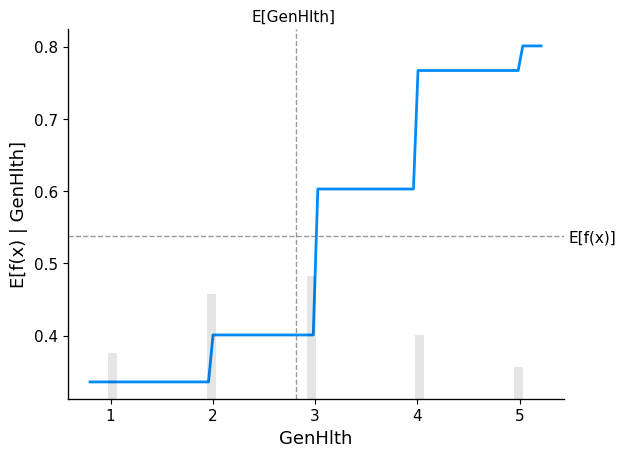

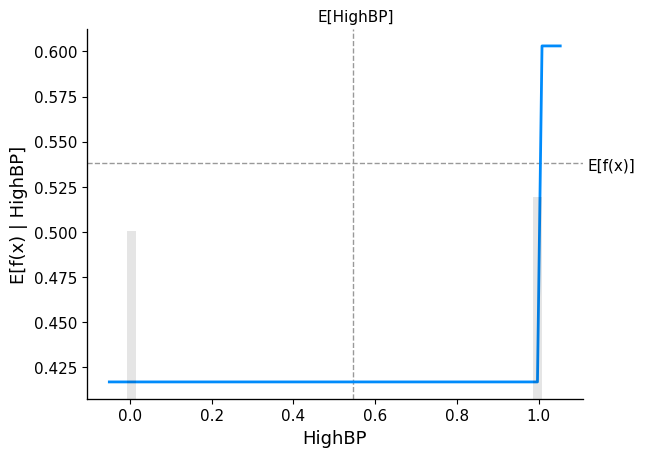

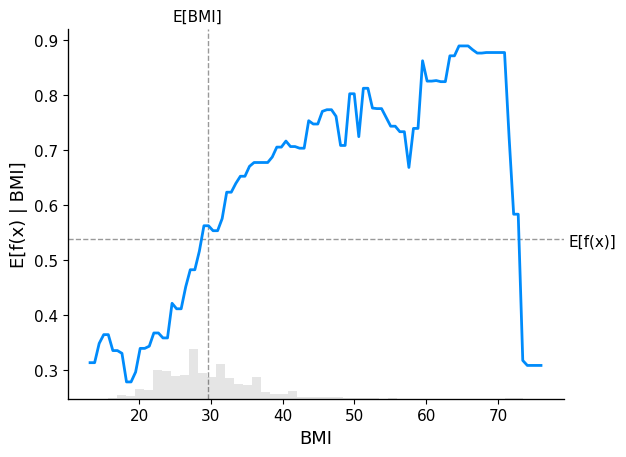

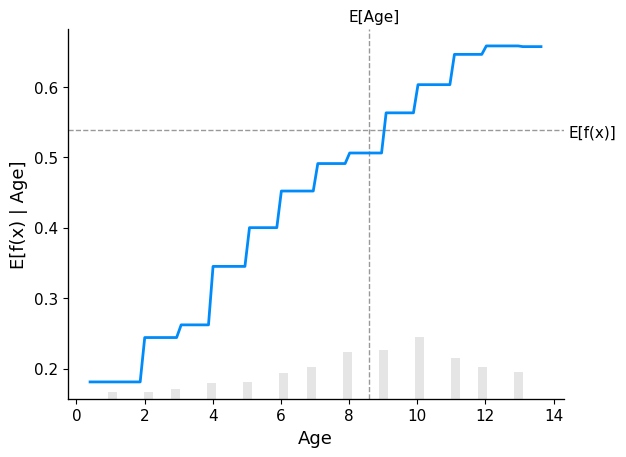

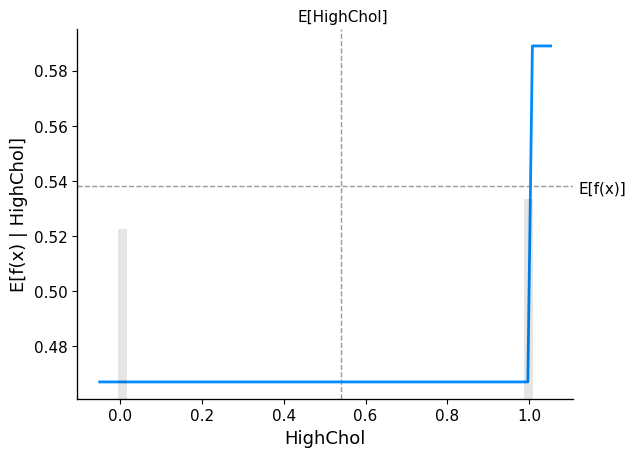

In [ ]:
# Inserte código para generar gráficos PDP aquí
# Generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones
X1000 = shap.utils.sample(X_test, 1000)

for name in top_features:
  shap.plots.partial_dependence(name,
                                pipeline.predict,
                                X1000,
                                model_expected_value=True,
                                feature_expected_value=True,
                                ice=False)

Analizando los gráficos tenemos para cada variable:

**Estado de salud autopercivido (`GenHlth`):**

En este grafico, vemos que a medida que el estado de salud aumenta (que empeora en este caso al ser una escala descendente donde 1 es excelente estado y 5 ha de ser fatal.), la probabilidad de que el modelo prediga diabetes (clase 1) tambien se incrementa. Esto sugiere que, en este dataset, el modelo identifica una relacion positiva entre GenHlth y el riesgo de diabetes. Es perfectamnte compatiblke que las personas que consideran tener mala salud presenten enfermedades, sobre todo enfermedades que suelen estar asociadas con la mala alimentacion y vida sedentaria (asociado a mala salud) como la diabetes.

---

**Presión Arterial Alta (`HighBP`):**

En el grafico de `HighBP`, notamos una diferencia significativa en la probabilidad predicha entre aquellos con hipertensión (H`ighBP = 1`) y aquellos sin ella (`HighBP = 0`). Las personas con presión arterial alta tienen una mayor probabilidad de ser clasificadas con diabetes por el modelo. Esto es consistente con el hecho de que la hipertensión suele estar asociada con un mayor riesgo de diabetes, dado que ambas condiciones están relacionadas con factores de riesgo comunes, como la obesidad y el sedentarismo.

---

**Indice de masa corporal (`IBM`):**

La relacion entre `IBM` y Diabetes es más compleja y muestra una variabilidad significativa en diferentes rangos. A pesar de esto, la variable tiene una clara tendencia a aumentar la probabilidad de diabetes  amedida que el indice de masa corporal aumenta, almneos hasta `IBM` = 70 donde esta relacion parce desplomarse lo cual podria deberse a interacciones no lineales con otras características o a la distribución de los datos originales (Tal vez la gente con Con IMBs tan altos que ademas presentan Diabetes no estan vivas para ser registradas 💀)


---

**Edad (`Age`):**

En este grafico, vemos que a medida que la edad aumenta, la probabilidad de que el modelo prediga diabetes (clase 1) tambien se incrementa. Esto sugiere que, en este dataset, el modelo identifica una relacion positiva entre la edad y el riesgo de diabetes. Es común que la edad sea un factor de riesgo en la diabetes (al menos para la tipo 2), aunque aquí el modelo parece estar capturando un patrón general de mayor probabilidad de diabetes en personas mayores.

---

**Colesterol Alto (`HighChol`)**:

Este grafico es quivalente al de `HighBP`. Por tanto, las personas con un nivel de Colesterol alto tienen una mayor probabilidad de ser clasificadas con diabetes por el modelo. Esto es consistente con el hecho de que la diabetes tiende a disminuir los niveles de colesterol HDL (considerado "bueno") y aumentar los niveles de LDL (colesterol "malo") y asumo que estos ultimos son los que los nos proporcionan los datos.



## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [ ]:
!pip install alibi

In [ ]:
from alibi.explainers import AnchorTabular

In [ ]:
# Inserte su código para generar sistema de reglas aquí

# Accedemos al modelo XGBoost desde el pipeline
xgb_model = pipeline.named_steps['classifier']

# Get feature names from the original data (X_train)
feature_names = X_train.columns.tolist()

predict_fn = lambda x: xgb_model.predict(x) # creamos función de predicción
explainer = AnchorTabular(predict_fn, feature_names, seed=42) # instanciamos Anchor usando función creada

explainer.fit(X_train.to_numpy()) # sobre los datos

# Explicar cada observación solicitada

for idx in [1000, 3001, 5751]:
    obs = np.array(X_test.iloc[idx]).reshape(1, -1)  # Crear array para la observación

    # Generar la explicación para la observación transformada
    explanation = explainer.explain(obs, threshold=0.95)

    # Imprimir los resultados
    print(f"\nExplicación para la observación {idx}:")
    print("Predicción del modelo:", predict_fn(obs)[0])
    print("Anchor (regla): %s" % (' AND '.join(explanation.anchor)))
    print("Precisión del Anchor: %.2f" % explanation.precision)
    print("Cobertura del Anchor: %.2f" % explanation.coverage)


Explicación para la observación 1000:
Predicción del modelo: 1
Anchor (regla): HeartDiseaseorAttack > 0.00 AND HighBP > 0.00 AND BMI > 25.00 AND Age > 9.00
Precisión del Anchor: 0.96
Cobertura del Anchor: 0.06

Explicación para la observación 3001:
Predicción del modelo: 1
Anchor (regla): BMI > 33.00 AND HighBP > 0.00 AND GenHlth > 2.00
Precisión del Anchor: 0.97
Cobertura del Anchor: 0.15

Explicación para la observación 5751:
Predicción del modelo: 0
Anchor (regla): GenHlth <= 2.00 AND HighBP <= 0.00 AND BMI <= 25.00
Precisión del Anchor: 0.98
Cobertura del Anchor: 0.11


Analisemos las reglas propuestas:  

 * Regla para observacion 1000:

Esta regla combina varios factores de riesgo conocidos de la diabetes: personas que han reportado tener enfermedad cardíaca coronaria (EC) o infarto de miocardio, alta presion sanguinea , BMI (indice de masa corporal) de mas de 27, donde un numero mayor a 25 ya se considera a una persona con sobrepeso y una edad superior a 9 (codificacion que no conozco pero com 13 es el maximo se asume que no se trata de gente oven jaja). La combinación de estas condiciones seguramente refleja un perfil de riesgo alto, lo que hace que esta regla tenga alta precision (96%) pero baja cobertura (6%).

Aunque es muy precisa, la baja cobertura sugiere que esta regla aplica solo a una pequeña fracción del conjunto de datos. Por tanto, es una explicacion valida pero limitada en su alcance.

* Regla para observacion 3001:

La regla indica que las personas que no BMI mayor a 33 (Ya con mas de 30 estas clasificado con Obesidad), con alta presion sanguinea y con una percepcion de salud por arriba de dos (donde mas grande es peor salud)tienen una alta probabilidad de ser clasificadas como  diabeticas. Esto regla es muy similar a la anterior descontando la condicion de registro de enfermedades cardiacas, pero acotandoce  a personas con in BMI aun mas alto.

La regla tiene una cobertura de (15%), lo que sigue siendo una porción pequeña del conjunto de datos, pero con una alta precision (97%). Esto sugiere que es una regla que aplica explica un subconjunto de las observaciones o datos.

* Regla para la observación 5751:

La regla indica que las personas que perciben tener un buen estado de salud, con GenHlth menos o igual 2 (GenHlt va del 1 al 5 con 1 excelente y 5 fatal imagino jeje),  que poseen una presion arterial normales y que se encuentran en rangos adecuados de IBM tienen una alta probabilidad de ser clasificadas como no diabeticas.

Esta regla tiene una covertura del (11%) y una precisión del (98%), la covertura mas baja y precision mas alta de las reglas que exploramos.


Tomando esto en cunta, considero que las reglas tienen sentido en el contexto de los datos. Capturan relaciones que el modelo ha identificado como relevantes y que reflejan en cierta medida factores de riesgo conocidos de diabetes (como estado de salud, presion arterial y BMI). Sin embargo, algunas reglas, como la relacionada con el consumo de frutas, pueden reflejar correlaciones específicas de este conjunto de datos que podrían no generalizarse a pesar de tener la mayor cobertura de todas.

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

Consideramos que las reglas tienen sentido para explicar las predicciones individuales, pero su impacto global es mixto: algunas son más aplicables a todo el conjunto de datos, mientras que otras son útiles solo para subconjuntos específicos. Si se requiere mayor generalización, creemos que lo mas ser útil combinar estas reglas con el análisis de características globales que hicimos con los valores shap. En resumen:        

* Los valores SHAP globales son probablemente los mas utiles para obtener conclusiones sobre la importancia de las caracteristicas y su impacto en el modelo. Ofrecen informacion precisa sobre como cada caracteristica influye en el modelo, tanto en magnitud como en direccion, lo cual es invaluable para entender los factores de riesgo en la clasificacion de diabetes.

* Para explicaciones especificas, los SHAP valores locales y los anchors son ambos efectivos. Los valores SHAP locales son detallados y explican como cada característica afecta la prediccion en cada observacion, mientras que los anchors son mas directos al generar reglas interpretables.

Para el caso del Dr. Simi, como el esté interesado en entender por que su modelo predice diabetes para pacientes especificos y, ademas, quiera una vision general de los factores de riesgo sostenemos un enfoque hibrido que use metodos tanto locales como globales es el mas beneficioso para el problema del Dr. Simi, ya que permite conclusiones claras tanto a nivel individual como poblacional.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://media.tenor.com/ctnq4bhZE3gAAAAC/drsimi-simi.gif)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>